# Clustering Algorithms: From Zero to Hero
## Practical Jupyter Notebook
### Emmanuel Nyandu Kagarabi | SISSA / LADE – Area Science Park, Trieste 2026

This notebook contains **executable code** for classical clustering algorithms.All algorithms are implemented from scratch and with scikit-learn.

**Chapters:**
1. K-Means Clustering  
2. K-Medoids (PAM)  
3. Hierarchical Clustering  
4. DBSCAN  
5. Gaussian Mixture Models (GMM/EM)  
6. Spectral Clustering  
7. Fuzzy C-Means  
8. 🌟 Density Peak Clustering (DPC) — Rodriguez & Laio 2014


## 0. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.cluster import (KMeans, AgglomerativeClustering, DBSCAN,
                               SpectralClustering, MeanShift, estimate_bandwidth)
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)
print("Setup complete. scikit-learn ready.")

Setup complete. scikit-learn ready.


## Chapter 1: K-Means Clustering

### Core Idea
Minimise within-cluster sum of squares (WCSS):
$$\mathcal{J} = \sum_{k=1}^{K}\sum_{\mathbf{x}_i \in C_k} \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$$

Lloyd's algorithm alternates:
- **E-step**: assign each point to nearest centroid
- **M-step**: update centroid = mean of assigned points


Converged at iteration 2
WCSS: 14.9956 | Silhouette: 0.8403


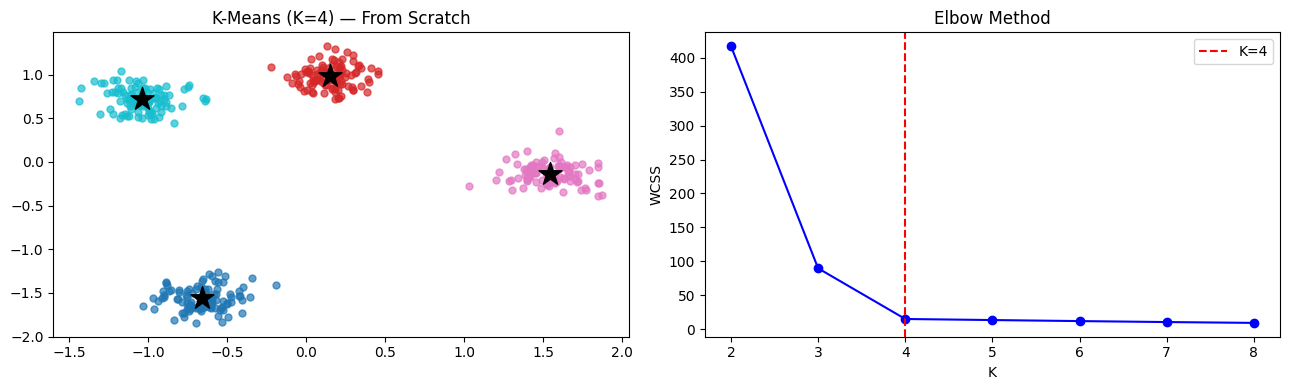

In [2]:
# ─── K-Means from SCRATCH ────────────────────────────────────────────
def kmeans_scratch(X, K, max_iter=300, tol=1e-4, seed=42):
    rng = np.random.default_rng(seed)
    # K-Means++ initialisation
    centroids = [X[rng.integers(len(X))]]
    for _ in range(K - 1):
        dists = np.array([min(np.linalg.norm(x-c)**2 for c in centroids) for x in X])
        centroids.append(X[rng.choice(len(X), p=dists/dists.sum())])
    centroids = np.array(centroids)
    labels = np.zeros(len(X), dtype=int)

    for t in range(max_iter):
        dists = np.linalg.norm(X[:, None] - centroids[None], axis=2)
        new_labels = np.argmin(dists, axis=1)
        new_centroids = np.array([X[new_labels==k].mean(axis=0) if (new_labels==k).any()
                                   else centroids[k] for k in range(K)])
        if np.allclose(centroids, new_centroids, atol=tol):
            print(f"Converged at iteration {t+1}")
            break
        centroids, labels = new_centroids, new_labels

    wcss = sum(np.sum((X[labels==k] - centroids[k])**2) for k in range(K))
    return labels, centroids, wcss

# Generate data
X, y = make_blobs(n_samples=400, centers=4, cluster_std=0.8, random_state=42)
X = StandardScaler().fit_transform(X)

# Run from scratch
labels, centroids, wcss = kmeans_scratch(X, K=4)
print(f"WCSS: {wcss:.4f} | Silhouette: {silhouette_score(X, labels):.4f}")

# Elbow method
K_range = range(2, 9)
wcss_list = [KMeans(n_clusters=K, n_init=10, random_state=42).fit(X).inertia_
             for K in K_range]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = plt.cm.tab10(np.linspace(0, 1, 4))
for k in range(4):
    m = labels == k
    axes[0].scatter(X[m,0], X[m,1], s=25, color=colors[k], alpha=0.7)
axes[0].scatter(centroids[:,0], centroids[:,1], marker='*', s=300, c='black', zorder=5)
axes[0].set_title('K-Means (K=4) — From Scratch')

axes[1].plot(K_range, wcss_list, 'bo-')
axes[1].axvline(x=4, color='red', linestyle='--', label='K=4')
axes[1].set_xlabel('K'); axes[1].set_ylabel('WCSS'); axes[1].set_title('Elbow Method')
axes[1].legend()
plt.tight_layout(); plt.show()

## Chapter 2: K-Medoids (PAM)

Medoids are **actual data points** (unlike centroids). More robust to outliers.
Works with any distance metric.

$$\mathcal{J} = \sum_{k=1}^{K}\sum_{\mathbf{x}_i \in C_k} d(\mathbf{x}_i, \mathbf{m}_k)$$


PAM total cost: 33.0307 | Silhouette: 0.7612


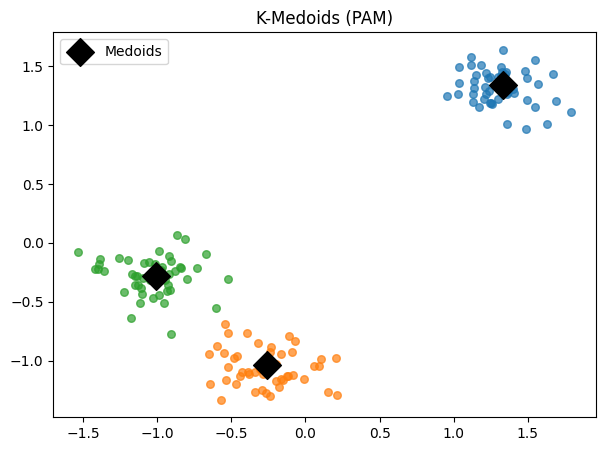

In [3]:
def pam(X, K, max_iter=50, seed=42):
    rng = np.random.default_rng(seed)
    n = len(X)
    D = pairwise_distances(X)
    medoid_idx = rng.choice(n, K, replace=False)

    def cost(meds):
        d = D[:, meds]; lbl = np.argmin(d, axis=1)
        return lbl, d[np.arange(n), lbl].sum()

    labels, total = cost(medoid_idx)
    for _ in range(max_iter):
        improved = False
        for k in range(K):
            non_med = [i for i in range(n) if i not in medoid_idx]
            for j in non_med:
                cand = medoid_idx.copy(); cand[k] = j
                _, nc = cost(cand)
                if nc < total - 1e-9:
                    medoid_idx, total = cand, nc; improved = True
        if not improved: break
    final_labels, final_cost = cost(medoid_idx)
    return final_labels, medoid_idx, final_cost

X_m, _ = make_blobs(n_samples=150, centers=3, cluster_std=0.8, random_state=1)
X_m = StandardScaler().fit_transform(X_m)
labels_m, medoids_m, cost_m = pam(X_m, K=3)
print(f"PAM total cost: {cost_m:.4f} | Silhouette: {silhouette_score(X_m, labels_m):.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
for k in range(3):
    m = labels_m == k
    ax.scatter(X_m[m,0], X_m[m,1], s=30, alpha=0.7)
ax.scatter(X_m[medoids_m,0], X_m[medoids_m,1],
           marker='D', s=200, c='black', zorder=5, label='Medoids')
ax.set_title('K-Medoids (PAM)'); ax.legend(); plt.show()

## Chapter 3: Hierarchical Clustering

Builds a tree (dendrogram) of nested clusters. No need to pre-specify K.

**Linkage functions** define distance between clusters:
- **Ward**: minimises WCSS increase
- **Complete**: maximum pairwise distance  
- **Single**: minimum pairwise distance


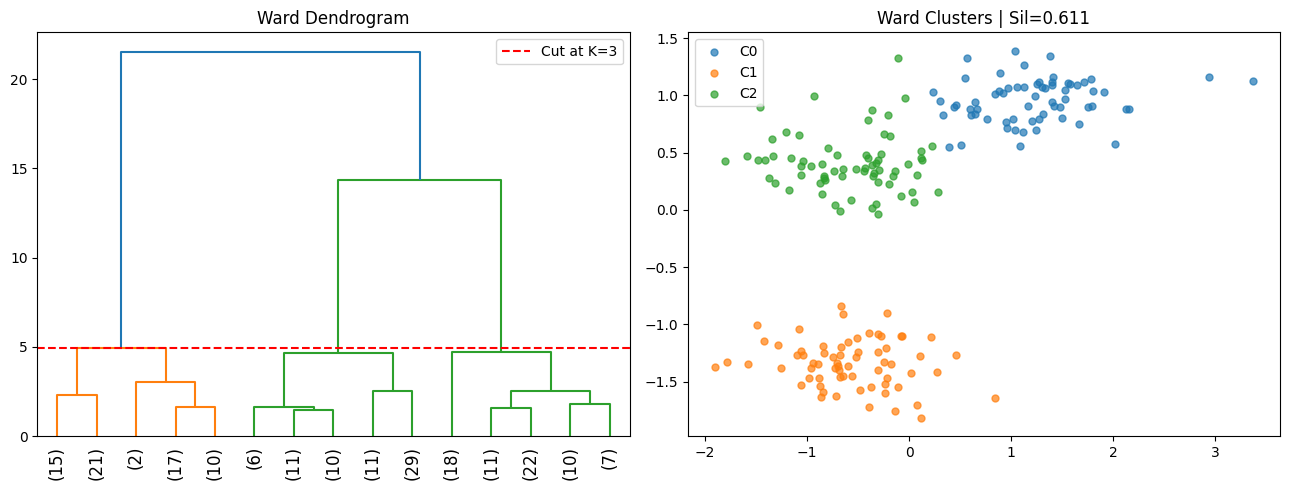

ward      : Silhouette = 0.6108
complete  : Silhouette = 0.6108
average   : Silhouette = 0.4907
single    : Silhouette = 0.4530


In [4]:
X_h, _ = make_blobs(n_samples=200, centers=3, cluster_std=0.7, random_state=2)
X_h = StandardScaler().fit_transform(X_h)

Z = linkage(X_h, method='ward')
labels_h = fcluster(Z, t=3, criterion='maxclust') - 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
dendrogram(Z, ax=axes[0], truncate_mode='lastp', p=15, leaf_rotation=90)
axes[0].axhline(y=Z[-3,2], color='red', linestyle='--', label='Cut at K=3')
axes[0].set_title('Ward Dendrogram'); axes[0].legend()

for k in range(3):
    m = labels_h == k
    axes[1].scatter(X_h[m,0], X_h[m,1], s=25, alpha=0.7, label=f'C{k}')
axes[1].set_title(f'Ward Clusters | Sil={silhouette_score(X_h, labels_h):.3f}')
axes[1].legend(); plt.tight_layout(); plt.show()

# Compare linkages
for link in ['ward', 'complete', 'average', 'single']:
    lbl = AgglomerativeClustering(n_clusters=3, linkage=link).fit_predict(X_h)
    print(f"{link:10s}: Silhouette = {silhouette_score(X_h, lbl):.4f}")

## Chapter 4: DBSCAN

Clusters = **dense regions** separated by sparse areas.

**Three types of points:**
- **Core**: $|N_\varepsilon(\mathbf{x})| \geq \text{MinPts}$
- **Border**: within $\varepsilon$ of a core point, but not core itself
- **Noise**: neither core nor border


Clusters: 6 | Noise: 5 | Sil: 0.2265


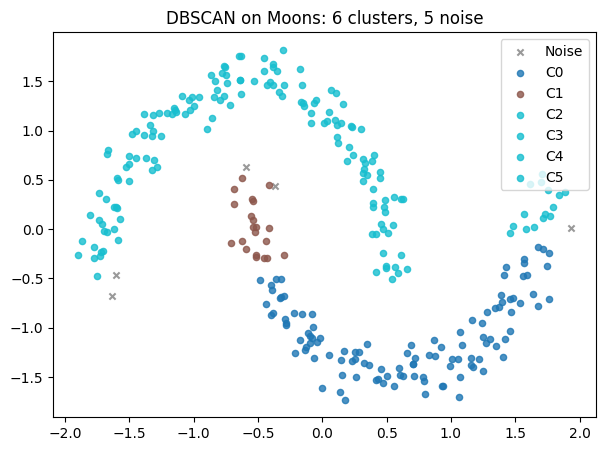

In [5]:
X_db, _ = make_moons(n_samples=300, noise=0.07, random_state=42)
X_db = StandardScaler().fit_transform(X_db)

db = DBSCAN(eps=0.2, min_samples=5).fit(X_db)
labels_db = db.labels_
n_cl = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()
print(f"Clusters: {n_cl} | Noise: {n_noise} | Sil: {silhouette_score(X_db, labels_db):.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
for lbl in sorted(set(labels_db)):
    m = labels_db == lbl
    c = 'grey' if lbl == -1 else plt.cm.tab10(lbl * 0.5)
    mk = 'x' if lbl == -1 else 'o'
    ax.scatter(X_db[m,0], X_db[m,1], s=20, c=[c], marker=mk, alpha=0.8,
               label='Noise' if lbl==-1 else f'C{lbl}')
ax.set_title(f'DBSCAN on Moons: {n_cl} clusters, {n_noise} noise')
ax.legend(); plt.show()

## Chapter 5: Gaussian Mixture Models (GMM / EM)

Each cluster modelled as a Gaussian. Soft (probabilistic) assignments.

$$p(\mathbf{x}) = \sum_{k=1}^{K}\pi_k\,\mathcal{N}(\mathbf{x};\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

**EM Algorithm:**
- **E-step**: compute responsibilities $r_{ik}$ (posterior probabilities)
- **M-step**: update $\pi_k, \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k$ to maximise expected log-likelihood


Best K by BIC: 4
Silhouette: 0.7743


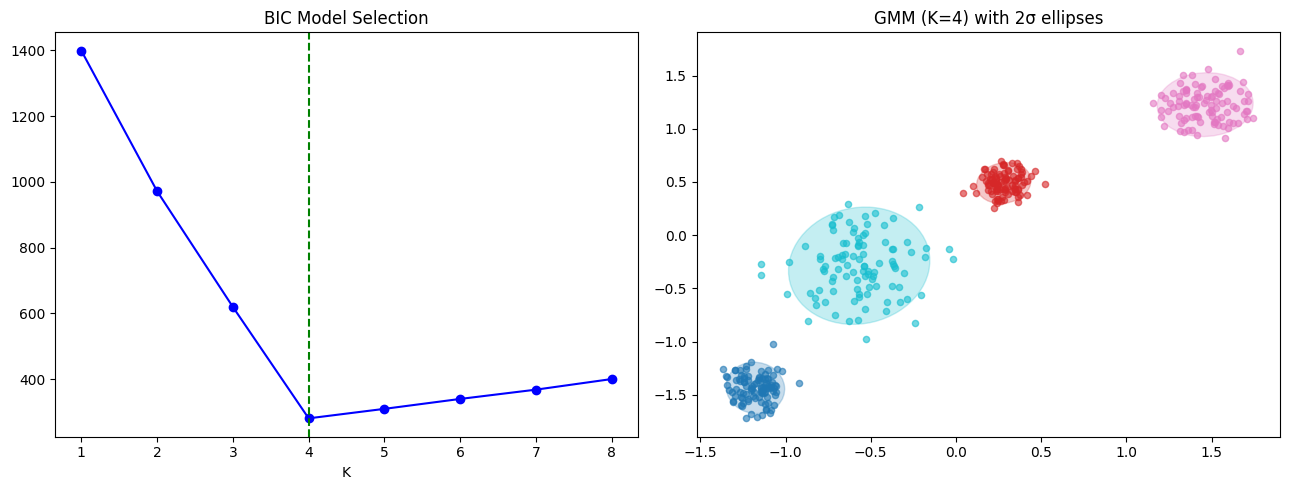

In [6]:
X_g, _ = make_blobs(n_samples=400, centers=4,
                     cluster_std=[0.5, 1.2, 0.8, 0.6], random_state=3)
X_g = StandardScaler().fit_transform(X_g)

# BIC model selection
bic = [GaussianMixture(n_components=K, n_init=5, random_state=42).fit(X_g).bic(X_g)
       for K in range(1, 9)]
best_K = np.argmin(bic) + 1
print(f"Best K by BIC: {best_K}")

gmm = GaussianMixture(n_components=best_K, n_init=10, random_state=42).fit(X_g)
labels_g = gmm.predict(X_g)
probs_g = gmm.predict_proba(X_g)
print(f"Silhouette: {silhouette_score(X_g, labels_g):.4f}")

def draw_ellipse(ax, mean, cov, color, alpha=0.25, n_std=2):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]; vals, vecs = vals[order], vecs[:,order]
    angle = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2*n_std*np.sqrt(vals)
    ax.add_patch(Ellipse(xy=mean, width=w, height=h, angle=angle, color=color, alpha=alpha))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(range(1,9), bic, 'bo-'); axes[0].axvline(x=best_K, color='g', linestyle='--')
axes[0].set_title('BIC Model Selection'); axes[0].set_xlabel('K')

colors_g = plt.cm.tab10(np.linspace(0, 1, best_K))
for k in range(best_K):
    m = labels_g == k
    axes[1].scatter(X_g[m,0], X_g[m,1], s=20, color=colors_g[k], alpha=0.6)
    draw_ellipse(axes[1], gmm.means_[k], gmm.covariances_[k], colors_g[k])
axes[1].set_title(f'GMM (K={best_K}) with 2σ ellipses')
plt.tight_layout(); plt.show()

## Chapter 6: Spectral Clustering

Works in the eigenspace of the **graph Laplacian** $L = D - W$.  
Powerful for non-convex cluster shapes (rings, crescents).

**Algorithm:**
1. Build similarity graph with RBF kernel
2. Compute $K$ smallest eigenvectors of $L$
3. Run K-Means on the eigenvector matrix rows


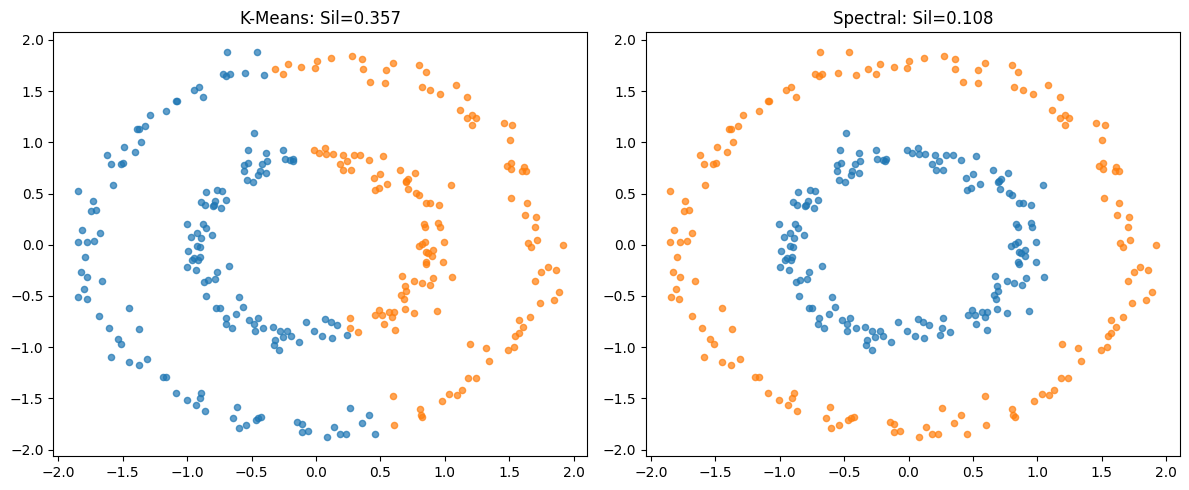

Notice: Spectral correctly separates the rings; K-Means fails!


In [7]:
X_sc, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=4)
X_sc = StandardScaler().fit_transform(X_sc)

km_lbl = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X_sc)
sc_lbl = SpectralClustering(n_clusters=2, affinity='rbf', gamma=10,
                               random_state=42).fit_predict(X_sc)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for col, (lbl, title) in enumerate([(km_lbl, 'K-Means'), (sc_lbl, 'Spectral')]):
    for k in range(2):
        axes[col].scatter(X_sc[lbl==k, 0], X_sc[lbl==k, 1], s=20, alpha=0.7)
    sil = silhouette_score(X_sc, lbl)
    axes[col].set_title(f'{title}: Sil={sil:.3f}')
plt.tight_layout(); plt.show()
print("Notice: Spectral correctly separates the rings; K-Means fails!")

## Chapter 7: Fuzzy C-Means

**Soft clustering**: each point has degree of belonging $u_{ik} \in [0,1]$ to each cluster.

$$\mathcal{J}_m = \sum_{i=1}^n \sum_{k=1}^K u_{ik}^m \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$$

Fuzziness exponent $m > 1$ (typically $m=2$).


FCM converged at iteration 128
Silhouette: 0.4763


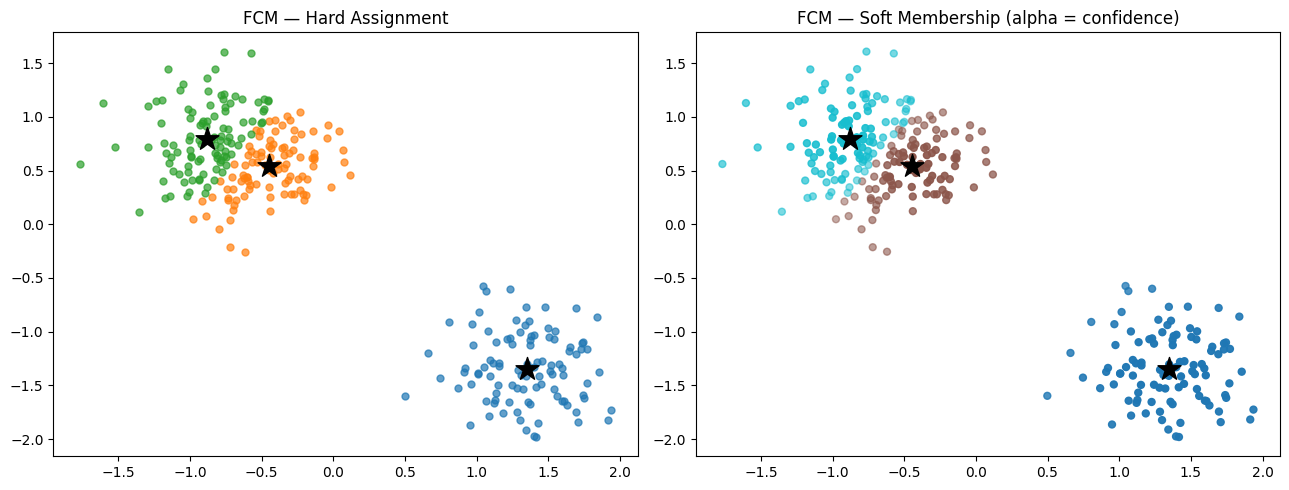

In [8]:
def fuzzy_cmeans(X, K, m=2.0, max_iter=300, tol=1e-6, seed=42):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    U = rng.random((n, K)); U /= U.sum(axis=1, keepdims=True)
    for t in range(max_iter):
        Um = U**m
        centroids = (Um.T @ X) / Um.sum(axis=0)[:,None]
        dists = np.maximum(np.linalg.norm(X[:,None] - centroids[None], axis=2), 1e-10)
        exp = 2/(m-1)
        U_new = np.zeros_like(U)
        for k in range(K):
            U_new[:,k] = 1.0 / ((dists[:,k:k+1]/dists)**exp).sum(axis=1)
        if np.linalg.norm(U_new - U) < tol:
            print(f"FCM converged at iteration {t+1}"); break
        U = U_new
    return U, centroids, np.argmax(U, axis=1)

X_fcm, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.9, random_state=5)
X_fcm = StandardScaler().fit_transform(X_fcm)
U_fcm, cent_fcm, lbl_fcm = fuzzy_cmeans(X_fcm, K=3)
print(f"Silhouette: {silhouette_score(X_fcm, lbl_fcm):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for k in range(3):
    m = lbl_fcm == k
    axes[0].scatter(X_fcm[m,0], X_fcm[m,1], s=25, alpha=0.7)
axes[0].scatter(cent_fcm[:,0], cent_fcm[:,1], marker='*', s=300, c='black', zorder=5)
axes[0].set_title('FCM — Hard Assignment')

axes[1].scatter(X_fcm[:,0], X_fcm[:,1], s=25, c=lbl_fcm, cmap='tab10',
                alpha=U_fcm.max(axis=1))
axes[1].scatter(cent_fcm[:,0], cent_fcm[:,1], marker='*', s=300, c='black', zorder=5)
axes[1].set_title('FCM — Soft Membership (alpha = confidence)')
plt.tight_layout(); plt.show()

## Chapter 8: 🌟 Density Peak Clustering (DPC)

**Rodriguez & Laio, Science 2014** — *"Clustering by fast search and find of density peaks"*

### The Core Insight
Cluster centres are points that are:
1. **High local density** $\rho_i$ — many neighbours nearby
2. **Far from any higher-density point** $\delta_i$ — isolated peak

$$\rho_i = \sum_{j \neq i} e^{-(d_{ij}/d_c)^2}, \qquad \delta_i = \min_{j:\, \rho_j > \rho_i} d_{ij}$$

**Gamma score**: $\gamma_i = \rho_i \times \delta_i$ — large for centres, small for non-centres.

### Why DPC is Special
| Property | Classical | DPC |
|---|---|---|
| Centre definition | Centroid/medoid | **Density peak** |
| Shape assumption | Spherical/parametric | **None** |
| Convergence | Iterative | **Single pass** |
| Distance type | Often Euclidean | **Any metric** |
| Noise | Via heuristics | **Via halo** |


In [9]:
# ─── DPC COMPLETE IMPLEMENTATION ─────────────────────────────────────
def compute_rho(D, dc, kernel='gaussian'):
    if kernel == 'gaussian':
        return np.sum(np.exp(-(D/dc)**2), axis=1) - 1.0
    return np.sum(D < dc, axis=1).astype(float) - 1.0

def compute_delta(D, rho):
    n = len(rho)
    delta = np.full(n, np.inf); nh = np.full(n, -1, dtype=int)
    for i in range(n):
        mask = rho > rho[i]
        if mask.any():
            d_hi = D[i, mask]; best = np.argmin(d_hi)
            delta[i] = d_hi[best]; nh[i] = np.where(mask)[0][best]
    delta[np.argmax(rho)] = D[np.argmax(rho)].max()
    return delta, nh

def assign_clusters(rho, nh, centres):
    n = len(rho); labels = np.full(n, -1, dtype=int)
    for lbl, c in enumerate(centres): labels[c] = lbl
    for i in np.argsort(rho)[::-1]:
        if labels[i] == -1 and nh[i] >= 0 and labels[nh[i]] != -1:
            labels[i] = labels[nh[i]]
    return labels

def dpc(X, n_clusters, dc=None, kernel='gaussian'):
    D = pairwise_distances(X)
    if dc is None:
        flat = D[np.triu_indices_from(D, k=1)]
        dc = np.percentile(flat, 2.0)
        print(f"  Auto dc = {dc:.4f}")
    rho = compute_rho(D, dc, kernel)
    delta, nh = compute_delta(D, rho)
    gamma = rho * delta
    centres = np.argsort(gamma)[::-1][:n_clusters]
    labels = assign_clusters(rho, nh, centres)
    return labels, rho, delta, gamma, centres

print("DPC implementation ready!")

DPC implementation ready!


[Blobs]
Silhouette: 0.6019


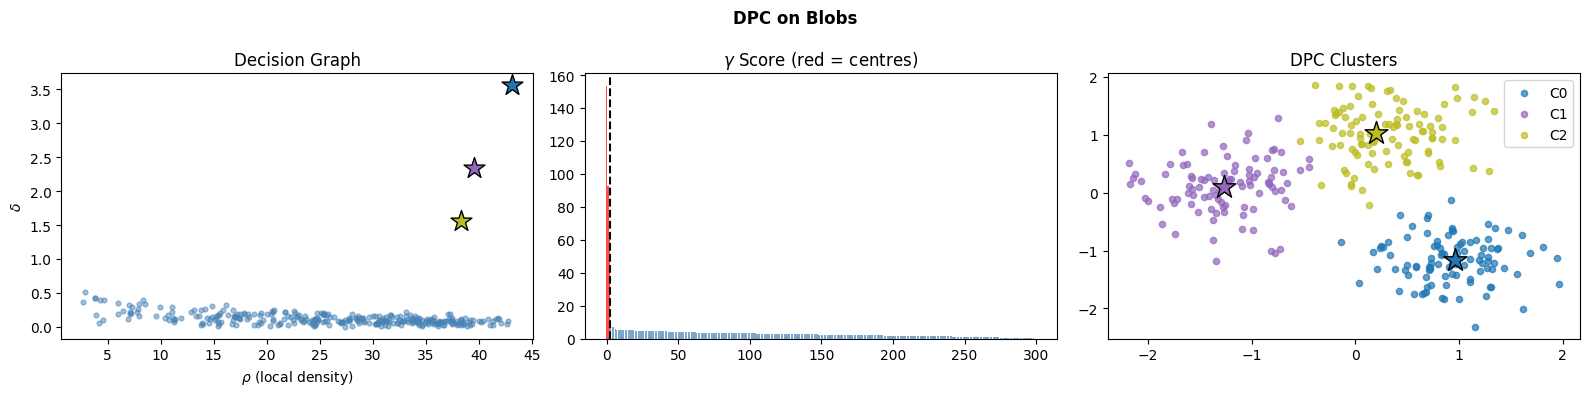

In [10]:
# ─── Experiment 1: Blobs ─────────────────────────────────────────────
X1, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.7, random_state=0)
X1 = StandardScaler().fit_transform(X1)
print("[Blobs]")
lb1, rho1, delta1, gamma1, cent1 = dpc(X1, n_clusters=3, dc=0.5)
print(f"Silhouette: {silhouette_score(X1, lb1):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('DPC on Blobs', fontsize=12, fontweight='bold')

# Decision graph
axes[0].scatter(rho1, delta1, s=12, c='steelblue', alpha=0.5)
colors1 = plt.cm.tab10(np.linspace(0, 0.8, 3))
for i, c in enumerate(cent1):
    axes[0].scatter(rho1[c], delta1[c], s=250, c=[colors1[i]],
                    marker='*', edgecolors='k', zorder=5)
axes[0].set_xlabel(r'$\rho$ (local density)'); axes[0].set_ylabel(r'$\delta$')
axes[0].set_title('Decision Graph')

# Gamma
sorted_g = np.sort(gamma1)[::-1]
bar_c = ['red' if i < 3 else 'steelblue' for i in range(len(gamma1))]
axes[1].bar(range(len(gamma1)), sorted_g, color=bar_c, alpha=0.7)
axes[1].axvline(x=2.5, color='black', linestyle='--')
axes[1].set_title(r'$\gamma$ Score (red = centres)')

# Assignment
for k in range(3):
    m = lb1 == k
    axes[2].scatter(X1[m,0], X1[m,1], s=20, c=[colors1[k]], alpha=0.7, label=f'C{k}')
for k, c in enumerate(cent1):
    axes[2].scatter(X1[c,0], X1[c,1], s=300, c=[colors1[k]],
                    marker='*', edgecolors='black', lw=1, zorder=5)
axes[2].set_title(f'DPC Clusters'); axes[2].legend()
plt.tight_layout(); plt.show()

[Moons]
Silhouette: 0.3773


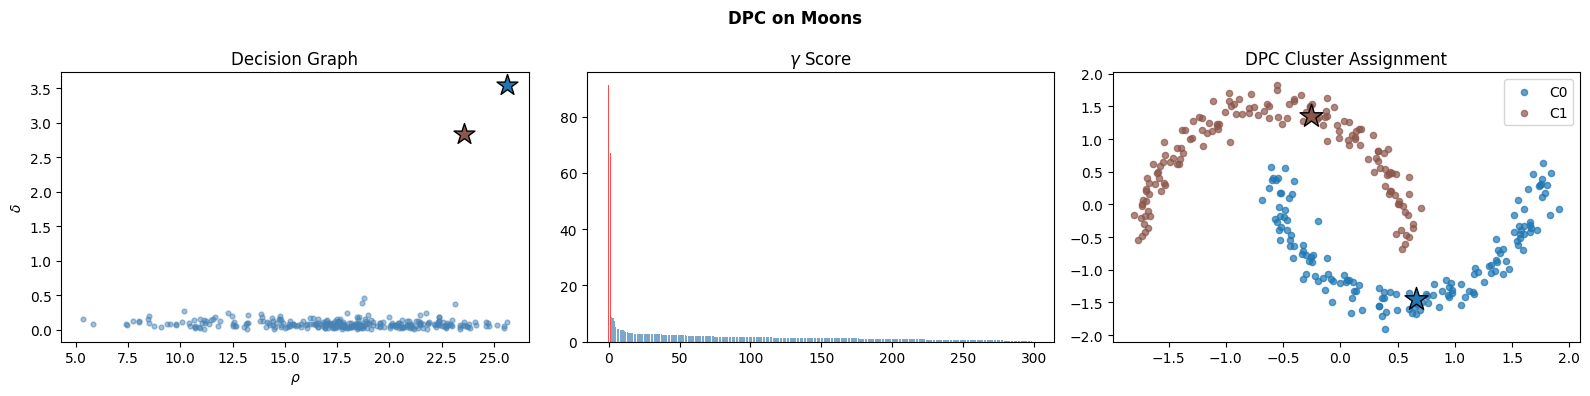

In [11]:
# ─── Experiment 2: Moons (non-convex) ────────────────────────────────
X2, _ = make_moons(n_samples=300, noise=0.07, random_state=7)
X2 = StandardScaler().fit_transform(X2)
print("[Moons]")
lb2, rho2, delta2, gamma2, cent2 = dpc(X2, n_clusters=2, dc=0.4)
print(f"Silhouette: {silhouette_score(X2, lb2):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('DPC on Moons', fontsize=12, fontweight='bold')
colors2 = plt.cm.tab10([0, 0.5])

axes[0].scatter(rho2, delta2, s=12, c='steelblue', alpha=0.5)
for i, c in enumerate(cent2):
    axes[0].scatter(rho2[c], delta2[c], s=250, c=[colors2[i]], marker='*',
                    edgecolors='k', zorder=5)
axes[0].set_xlabel(r'$\rho$'); axes[0].set_ylabel(r'$\delta$')
axes[0].set_title('Decision Graph')

sorted_g2 = np.sort(gamma2)[::-1]
axes[1].bar(range(len(gamma2)), sorted_g2,
            color=['red' if i<2 else 'steelblue' for i in range(len(gamma2))], alpha=0.7)
axes[1].set_title(r'$\gamma$ Score')

for k in range(2):
    m = lb2 == k
    axes[2].scatter(X2[m,0], X2[m,1], s=20, c=[colors2[k]], alpha=0.7, label=f'C{k}')
for k, c in enumerate(cent2):
    axes[2].scatter(X2[c,0], X2[c,1], s=300, c=[colors2[k]],
                    marker='*', edgecolors='black', lw=1, zorder=5)
axes[2].set_title('DPC Cluster Assignment'); axes[2].legend()
plt.tight_layout(); plt.show()

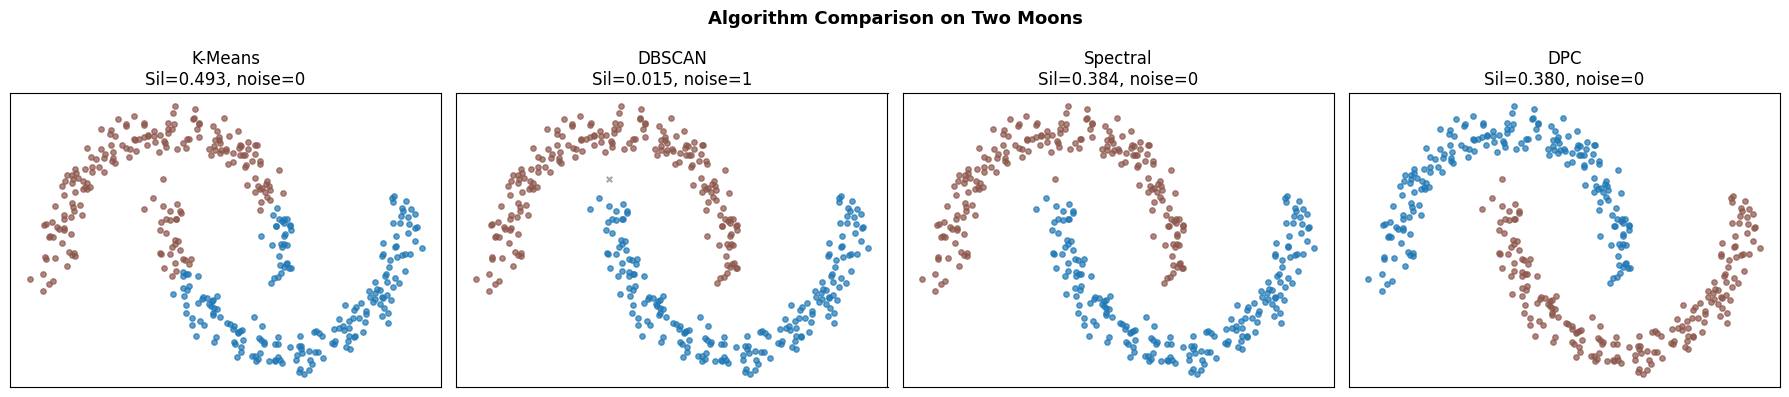


Key takeaway: DPC correctly identifies both moon-shaped clusters
using a single-pass cascade assignment from density peaks!


In [12]:
# ─── DPC vs Classical Algorithms ────────────────────────────────────
X_cmp, _ = make_moons(n_samples=400, noise=0.08, random_state=10)
X_cmp = StandardScaler().fit_transform(X_cmp)

lb_km = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X_cmp)
lb_db = DBSCAN(eps=0.25, min_samples=5).fit_predict(X_cmp)
lb_sc = SpectralClustering(n_clusters=2, affinity='rbf', gamma=10,
                              random_state=42).fit_predict(X_cmp)
lb_dpc, *_ = dpc(X_cmp, n_clusters=2, dc=0.35)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Algorithm Comparison on Two Moons', fontsize=13, fontweight='bold')

for col, (lbl, name) in enumerate([
        (lb_km, 'K-Means'), (lb_db, 'DBSCAN'),
        (lb_sc, 'Spectral'), (lb_dpc, 'DPC')]):
    ax = axes[col]
    unique = sorted(set(lbl))
    for l in unique:
        m = lbl == l
        c = 'grey' if l == -1 else plt.cm.tab10(l*0.5)
        ax.scatter(X_cmp[m,0], X_cmp[m,1], s=15, c=[c],
                   marker='x' if l==-1 else 'o', alpha=0.7)
    n_noise = (lbl==-1).sum()
    try:
        sil = silhouette_score(X_cmp, lbl)
        ax.set_title(f'{name}\nSil={sil:.3f}, noise={n_noise}')
    except:
        ax.set_title(f'{name}\nnoise={n_noise}')
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(); plt.show()
print("\nKey takeaway: DPC correctly identifies both moon-shaped clusters")
print("using a single-pass cascade assignment from density peaks!")

## Summary & Key Takeaways

| Algorithm | Strengths | Weaknesses |
|---|---|---|
| K-Means | Fast, scalable | Spherical clusters, needs K |
| K-Medoids | Robust, any distance | Slow O(n²) |
| Hierarchical | Dendrogram view | O(n² log n), not scalable |
| DBSCAN | Finds noise, arbitrary shape | Global ε, struggles with varying density |
| HDBSCAN | Variable density | More complex |
| GMM/EM | Soft assignments, elliptical | Needs K, sensitive to init |
| Spectral | Non-convex shapes | O(n³), needs K |
| Fuzzy C-Means | Soft memberships | Spherical, needs K |
| **DPC** | **Any shape, any distance, no iterations** | **O(n²) distances, dc choice** |

### DPC in Scientific Practice
DPC powers the protein domain databases :
- **DPCfam** (Russo et al. 2022): sequences clustered via profile-HMM E-values
- **DPCstruct** (Barone et al. 2025): structures clustered via TM-score distances

The algorithm's ability to handle **non-Euclidean distances** and **arbitrary cluster shapes** makes it ideal for protein domain space.

---
*Emmanuel Nyandu Kagarabi | SISSA | emmanuelnyandukagarabi.github.io*
